<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/BocResearchKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('/content/BOC_Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27
...,...,...,...
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27
708,Great app.. easy to access all services. Pleas...,2023-09-30T19:58:34,1.2.27
709,ð¥ð,2023-09-29T03:17:55,1.2.27


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...
...,...,...,...,...
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga
708,Great app.. easy to access all services. Pleas...,2023-09-30T19:58:34,1.2.27,great app easy access services please change b...
709,ð¥ð,2023-09-29T03:17:55,1.2.27,


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Vectorizer the data
#vectorizer = TfidfVectorizer()
#X_Vector = vectorizer.fit_transform(df['cleaned_content'])

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
df

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp,0.0000,negative
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui,-0.7906,negative
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used,-0.6249,negative
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...,0.0000,negative
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...,-0.7527,negative
...,...,...,...,...,...,...
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job,-0.2498,negative
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga,0.0000,negative
708,Great app.. easy to access all services. Pleas...,2023-09-30T19:58:34,1.2.27,great app easy access services please change b...,0.9260,positive
709,ð¥ð,2023-09-29T03:17:55,1.2.27,,0.0000,negative


In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,547
positive,164


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp,0.0000,negative
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui,-0.7906,negative
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used,-0.6249,negative
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...,0.0000,negative
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...,-0.7527,negative
...,...,...,...,...,...,...
705,Worst banking app in Sri Lanka,2023-10-02T11:23:30,1.2.27,worst banking app sri lanka,-0.6249,negative
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job,-0.2498,negative
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga,0.0000,negative
709,ð¥ð,2023-09-29T03:17:55,1.2.27,,0.0000,negative


In [ ]:
#Convert text to a Bag-of-Words representation
#vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
#dtm = vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: mobile, times, loading, user, lanka, sri, open, useless, service, boc, login, log, ca, work, connect, bank, server, time, app, slow
Topic 2: horrible, transfer, update, seen, access, need, really, error, properly, use, online, experience, application, poor, bad, used, working, banking, worst, app


In [ ]:
# Extract the word-topic matrix from the LDA model
topic_word_matrix = lda.components_

In [ ]:
# Create a DataFrame for better visualization and ranking
keywords_ranking = {}

In [ ]:
for topic_idx, topic_weights in enumerate(topic_word_matrix):
    # Get the feature names (keywords)
    keywords = feature_names

    # Create a DataFrame with keywords and their importance scores
    keyword_scores = pd.DataFrame({
        'Keyword': keywords,
        'Importance': topic_weights
    })

    # Sort by importance in descending order
    keyword_scores = keyword_scores.sort_values(by='Importance', ascending=False)

    # Add to the dictionary
    keywords_ranking[f"Topic {topic_idx + 1}"] = keyword_scores

In [ ]:
# Display the rankings for each topic
for topic, df in keywords_ranking.items():
    print(f"\n{topic} - Top Keywords with Importance:")
    print(df.head(20))  # Display the top 10 keywords for each topic


Topic 1 - Top Keywords with Importance:
     Keyword  Importance
288     slow   21.720166
15       app   20.824115
316     time   20.155172
279   server   18.363541
26      bank   13.485567
55   connect   12.626325
369     work   12.476516
42        ca   12.018451
175      log   11.890931
177    login   10.629977
35       boc    9.631725
281  service    9.406145
349  useless    9.330003
213     open    9.328764
296      sri    9.215608
162    lanka    8.877942
350     user    8.518571
172  loading    8.035875
317    times    7.824575
196   mobile    7.757513

Topic 2 - Top Keywords with Importance:
         Keyword  Importance
15           app   61.535975
375        worst   55.788319
27       banking   33.693765
371      working   24.103618
348         used   20.388519
24           bad   19.351070
236         poor   15.810517
16   application    9.194154
103   experience    8.850222
212       online    8.267025
347          use    7.388609
246     properly    7.199204
98         error

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
def generate_wordcloud(topic_df, topic_name):
    # Convert keywords and importance scores into a dictionary
    word_freq = {row['Keyword']: row['Importance'] for _, row in topic_df.iterrows()}

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(topic_name, fontsize=14)
    plt.show()

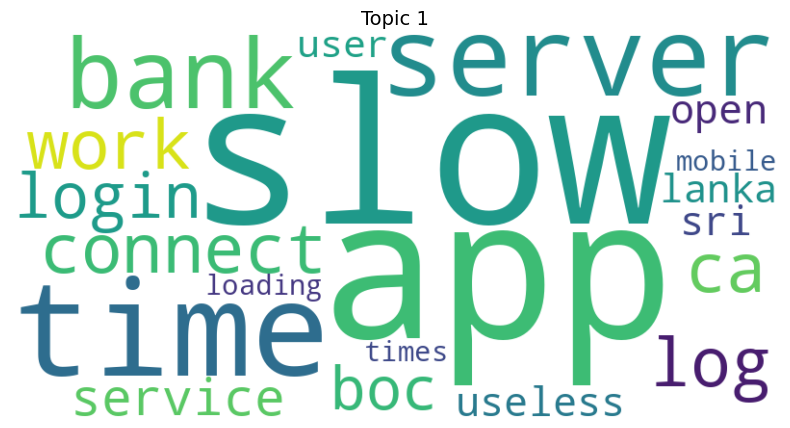

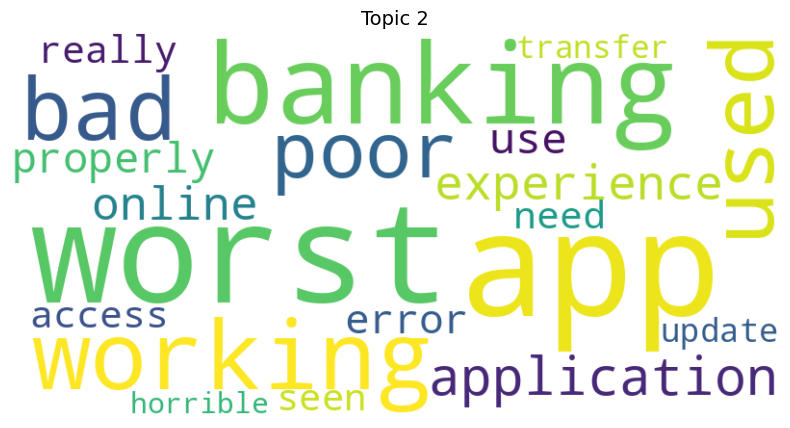

In [ ]:
# Generate word clouds for both topics
for topic, df in keywords_ranking.items():
    generate_wordcloud(df.head(20), topic)

In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-18-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
#negative_reviews

In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-19-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
0,It's time to do the Revamp ð´,2024-12-01T17:38:26,1.2.27,time revamp,0.0000,negative,0,UI
1,Bad UX experience and Bad UI,2024-11-30T09:53:50,1.2.27,bad ux experience bad ui,-0.7906,negative,1,UX
2,The worst app I ever used,2024-11-30T03:47:02,1.2.27,worst app ever used,-0.6249,negative,1,UX
3,This app needs a revision soon. All other comp...,2024-11-29T03:49:26,1.2.27,app needs revision soon competitors adopted bi...,0.0000,negative,1,UX
4,Worst banking app ever. Not user friendly at a...,2024-11-25T23:17:11,1.2.27,worst banking app ever user friendly leading b...,-0.7527,negative,0,UI
...,...,...,...,...,...,...,...,...
705,Worst banking app in Sri Lanka,2023-10-02T11:23:30,1.2.27,worst banking app sri lanka,-0.6249,negative,0,UI
706,Not perfect but it does the job,2023-10-02T05:29:54,1.2.27,perfect job,-0.2498,negative,0,UI
707,I think 2000 years OLD app develepors workinga.,2023-10-02T02:40:43,1.2.27,think 2000 years old app develepors workinga,0.0000,negative,1,UX
709,ð¥ð,2023-09-29T03:17:55,1.2.27,,0.0000,negative,0,UI


In [ ]:
negative_reviews['classification'].value_counts()

,count
classification,
UI,305
UX,242


In [ ]:
# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

In [ ]:
# K-Fold Cross-Validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
mse_values = []

In [ ]:
# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# Ensure X and Y are NumPy arrays
X = np.array(X)  # Convert X to a NumPy array if it isn't already
Y = np.array(Y)  # Convert Y to a NumPy array if it isn't already

In [ ]:
for train_index, test_index in kf.split(X, Y):
    # Direct indexing for NumPy arrays
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Train and evaluate KNN
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    fold_accuracies.append(accuracy_score(Y_test, Y_pred))

    # Calculate MSE (Mean Squared Error)
    mse_values.append(mean_squared_error(Y_test, Y_pred))


In [ ]:
# Print results
print(f"KNN Fold Accuracies: {fold_accuracies}")
print(f"KNN Mean Accuracy: {sum(fold_accuracies) / len(fold_accuracies):.2f}")


KNN Fold Accuracies: [0.7363636363636363, 0.7545454545454545, 0.7064220183486238, 0.7614678899082569, 0.7798165137614679]
KNN Mean Accuracy: 0.75


In [ ]:
print(f"KNN Fold MSE Values: {mse_values}")
print(f"KNN Mean MSE: {sum(mse_values) / len(mse_values):.2f}")

KNN Fold MSE Values: [0.2636363636363636, 0.24545454545454545, 0.29357798165137616, 0.23853211009174313, 0.22018348623853212]
KNN Mean MSE: 0.25


In [ ]:
# Detailed Classification Report
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))
# Or individual scores
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Classification Report:
              precision    recall  f1-score   support

          UI       0.73      0.97      0.83        61
          UX       0.93      0.54      0.68        48

    accuracy                           0.78       109
   macro avg       0.83      0.75      0.76       109
weighted avg       0.82      0.78      0.77       109

Precision: 0.93
Recall: 0.54
F1 Score: 0.68


In [ ]:
# Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(Y_test, Y_pred)
print(conf_matrix)


Confusion Matrix:
[[59  2]
 [22 26]]


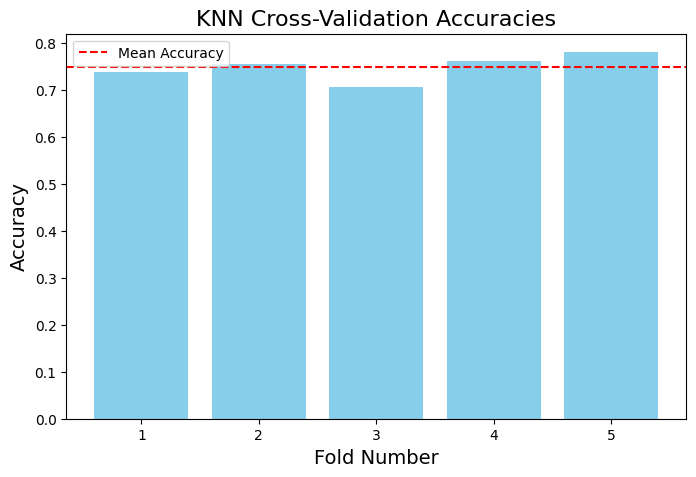

In [ ]:
# Plot the accuracies
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_accuracies) + 1), fold_accuracies, color='skyblue')
plt.axhline(y=np.mean(fold_accuracies), color='r', linestyle='--', label='Mean Accuracy')
plt.title('KNN Cross-Validation Accuracies', fontsize=16)
plt.xlabel('Fold Number', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(range(1, len(fold_accuracies) + 1))
plt.legend()
plt.show()